# RNA Based Isotype Identification Notebook

## Read in Libraries

In [1]:
### LIBRARIES ###
library(Seurat)
library(ggridges)
library(H5weaver)
library(ggplot2)
library(magrittr)
library(data.table)
library(dplyr)
library(ggplot2)
library(scRepertoire)
library(stringr)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: data.table

Warning message:
“package ‘data.table’ was built under R version 4.4.2”
Loading required package: Matrix

Warning message:
“package ‘Matrix’ was built under R version 4.4.2”
Loading required package: rhdf5

Warning message:
“package ‘rhdf5’ was built under R version 4.4.2”

Attaching package: ‘H5weaver’


The following objects are masked from ‘package:rhdf5’:

    h5dump, h5ls



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Functions

In [2]:
updated_read_h5_seurat <- function(h5_file,
                           target = "matrix",
                           feature_names = "name",
                           ...) {

  if(!requireNamespace("Seurat", versionCheck = list(op = ">=", version = "3.1.0"))) {
    stop("Can't find the Seurat package. Please install with install.packages(\"Seurat\")")
  }

  assertthat::assert_that(is.character(h5_file))
  assertthat::assert_that(length(h5_file) == 1)
  assertthat::assert_that(typeof(feature_names) == "character")
  assertthat::assert_that(length(feature_names) == 1)
  assertthat::assert_that(feature_names %in% c("id","name"))

  mat <- read_h5_dgCMatrix(h5_file,
                           target = target,
                           feature_names = feature_names)

  cell_meta <- read_h5_cell_meta(h5_file,
                                 target = target)
  rownames(cell_meta) <- cell_meta$barcodes

  rownames(cell_meta) <- cell_meta$barcodes
  feat_meta <- read_h5_feature_meta(h5_file,
                                    target = target)
  rownames(feat_meta) <- make.unique(feat_meta[[feature_names]])

  cite_10x <- FALSE
  cite_injected <- FALSE

  # Check for cellranger CITE-seq data
  if("feature_type" %in% names(feat_meta)) {
    if("Antibody Capture" %in% feat_meta$feature_type) {
      cite_10x <- TRUE
    }
  }

  if(cite_10x) {
    cite_feat <- feat_meta[feat_meta$feature_type == "Antibody Capture",]
    feat_meta <- feat_meta[feat_meta$feature_type != "Antibody Capture",]

    cite_mat <- mat[cite_feat$id,]
    mat <- mat[feat_meta$id,]
  }
    
  # Check for injected CITE-seq data
  if("ADT" %in% h5ls(h5_file)$name) {
    cite_injected <- TRUE
  }

  if(cite_injected) {
    cite_mat <- read_h5_dgCMatrix(h5_file, "ADT", feature_names = "id")
    colnames(cite_mat) <- cell_meta$barcodes
    cite_feat <- read_h5_feature_meta(h5_file, target = "ADT")
    rownames(cite_feat) <- make.unique(cite_feat[["id"]])
  }
  unique_rownames <- make.unique(rownames(mat))
  rownames(mat) <- unique_rownames
  so <- Seurat::CreateSeuratObject(counts = mat,
                                   meta.data = cell_meta,
                                   ...)
  so[["RNA"]] <- Seurat::AddMetaData( so[["RNA"]], feat_meta)
      
  if(cite_10x|cite_injected) {
    so[["ADT"]] <- Seurat::CreateAssayObject(counts = cite_mat)
    so[["ADT"]] <- Seurat::AddMetaData( so[["ADT"]], cite_feat)
  }

  so
}

In [3]:
build_so_plus_bcr <- function(sample_name){
    # build seurat object
    h5_path <- list.files(path = 'h5_input', pattern = sample_name, full.names = TRUE)
    so <- updated_read_h5_seurat(h5_path)

    # read bcr data
    bcr_path <- list.files(path = 'bcr_files', pattern = sample_name, full.names = TRUE)
    bcr <- read.csv(bcr_path)
    combined.BCR <- combineBCR(bcr,
                               samples = sample_name,
                               threshold = 0.85)

    # remove silly barcode addition from scRepertoire
    combined.BCR[[1]]$barcode <- str_sub(string = combined.BCR[[1]]$barcode, start = (nchar(sample_name)+2), end = nchar(combined.BCR[[1]]$barcode))

    # add BCR info to Seurat Object
    so <- combineExpression(combined.BCR, 
                            so, 
                            cloneCall="gene", 
                            group.by = "sample", 
                            proportion = TRUE)

    # split BCR info to get just IGH C gene usage
    so$igh_clone <- str_split_i(so$CTgene, pattern = '_', i = 1)
    so$igh_c_gene <- str_split_i(so$igh_clone, pattern = '[.]', i = -1)
    so$igl_clone <- str_split_i(so$CTgene, pattern = '_', i = 2)
    so$igl_c_gene <- str_split_i(so$igl_clone, pattern = '[.]', i = -1)

    return(so)
}

## Set up Seurat Object

In [4]:
sample_list <- c('SP00257-01-1','SP00257-01-2','SP00287-02-1','SP00287-02-2','SP01565-01-1','SP01565-01-2','SP01606-01-1','SP01606-01-2')

In [5]:
so_list <- lapply(sample_list, build_so_plus_bcr)

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with da

## Merge Objects

In [6]:
so <- Reduce(merge, so_list)

In [7]:
so

An object of class Seurat 
36641 features across 147710 samples within 2 assays 
Active assay: RNA (36601 features, 0 variable features)
 8 layers present: counts.1.1.1.1.1.1.1, counts.2, counts.2.1, counts.2.1.1, counts.2.1.1.1, counts.2.1.1.1.1, counts.2.1.1.1.1.1, counts.2.1.1.1.1.1.1
 1 other assay present: ADT

In [8]:
so <- JoinLayers(so)

In [9]:
table(so$igh_c_gene)


IGHA1 IGHA2  IGHD  IGHE IGHG1 IGHG2 IGHG3 IGHG4  IGHM IGLC1    NA 
 8542  1536  2326     3  4791  2375  1055    76 96021     1  6011 

In [10]:
table(so$igl_c_gene)


 IGKC IGLC1 IGLC2 IGLC3 IGLC7    NA 
68971 10059 33027  9475   240   965 

## Subset Seurat based on MuData object barcodes

In [11]:
mdata_obs <- read.csv('b_cell_barcodes.csv', row.names = 1)
head(mdata_obs)

,rna.adt_qc_flag,rna.adt_umis,rna.batch_id,rna.cell_name,rna.cell_uuid,rna.chip_id,rna.hto_barcode,rna.hto_category,rna.n_genes,rna.n_mito_umis,⋯,subject.birthYear,subject.ethnicity,subject.race,subject.subjectGuid,cohort.cohortGuid,age,leiden_wnn_0.8,leiden_wnn_0.6,leiden_wnn_1,cohort
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
17e8ad7646e111ee8b430242ac110002,Good,2566,EXP-00723,ingenious_moody_frog,17e8ad7646e111ee8b430242ac110002,EXP-00723-P1C1,ATTGACCCGCGTTAG,singlet,2456,184,⋯,1957,Non-Hispanic origin,Caucasian,BR2018,BR2,63,0,1,0,healthy
17e8b6f446e111ee8b430242ac110002,Good,3463,EXP-00723,cherubic_angsty_skipper,17e8b6f446e111ee8b430242ac110002,EXP-00723-P1C1,ATTGACCCGCGTTAG,singlet,2230,194,⋯,1957,Non-Hispanic origin,Caucasian,BR2018,BR2,63,0,1,0,healthy
17e8d21046e111ee8b430242ac110002,Good,2767,EXP-00723,quasipoor_limitless_sanddollar,17e8d21046e111ee8b430242ac110002,EXP-00723-P1C1,ATTGACCCGCGTTAG,singlet,2282,306,⋯,1957,Non-Hispanic origin,Caucasian,BR2018,BR2,63,5,5,5,healthy
17e8e03e46e111ee8b430242ac110002,Good,3087,EXP-00723,protective_cornmeal_pika,17e8e03e46e111ee8b430242ac110002,EXP-00723-P1C1,ATTGACCCGCGTTAG,singlet,2358,216,⋯,1957,Non-Hispanic origin,Caucasian,BR2018,BR2,63,8,0,8,healthy
17e8fd6246e111ee8b430242ac110002,Good,2543,EXP-00723,dry_awestruck_platypus,17e8fd6246e111ee8b430242ac110002,EXP-00723-P1C1,ATTGACCCGCGTTAG,singlet,2937,408,⋯,1957,Non-Hispanic origin,Caucasian,BR2018,BR2,63,0,1,0,healthy
17e90c1246e111ee8b430242ac110002,Good,4219,EXP-00723,surefooted_terracotta_martin,17e90c1246e111ee8b430242ac110002,EXP-00723-P1C1,ATTGACCCGCGTTAG,singlet,2363,178,⋯,1957,Non-Hispanic origin,Caucasian,BR2018,BR2,63,0,1,0,healthy


In [12]:
table(rownames(so@meta.data) %in% rownames(mdata_obs))


 FALSE   TRUE 
 36470 111240 

In [13]:
nrow(mdata_obs)

[1] 111240

In [14]:
so_mdata <- subset(so, cells = rownames(mdata_obs))

In [15]:
so_mdata

An object of class Seurat 
36641 features across 111240 samples within 2 assays 
Active assay: RNA (36601 features, 0 variable features)
 1 layer present: counts
 1 other assay present: ADT

In [16]:
table(so_mdata$igh_c_gene)


IGHA1 IGHA2  IGHD  IGHE IGHG1 IGHG2 IGHG3 IGHG4  IGHM IGLC1    NA 
 6863  1233  1995     2  3965  1938   938    65 89171     1  5069 

### Check Celltypist labels vs MuData barcodes

In [17]:
table(so_mdata$AIFI_PBMC_L1)


         B cell              DC             ILC        Monocyte         NK cell 
         109399             178             186              28             279 
       Platelet Progenitor cell          T cell 
             15             743             412 

## Check Clustering on Seurat Object

In [18]:
so_mdata <- NormalizeData(so_mdata) %>% FindVariableFeatures() %>% ScaleData() %>% RunPCA() %>% RunUMAP(dims=1:25)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  SPN, ANXA1, GNAQ, PLXDC2, ST8SIA6, TMEM173, ZNRF1, PRSS57, CD34, LRMDA 
	   ZNF385D, NKAIN2, NPR3, ERG, EMID1, SLC40A1, IGFBP7, LAPTM4B, INPP4B, GATA2 
	   MSRB3, CASC15, ATP8B4, MEIS1, EGFL7, PLCB1, ZNF521, IQGAP2, PRKCQ, FRMD4B 
Negative:  IGHM, TCL1A, JUNB, BACH2, IGHD, COL19A1, JUN, ACTB, KCNG1, LINC01857 
	   CAMK2D, LIX1-AS1, STAG3, AC108879.1, SLC2A3, AL139020.1, STEAP1B, SLC38A11, ARHGAP24, AREG 
	   IGLC3, IGKC, ID3, KLHL14, IL6, ST6GALNAC3, KCNH8, ADK, LARGE1, AC019197.1 
PC_ 2 
Positive:  CRIP1, TNFRSF13B, VOPP1, ITGB1, AHNAK, ANXA2, IGHA1, SSPN, HIPK2, CD27 
	   LGALS1, AL355076.2, CSGALNACT1, COL4A4, SOX5, PVT1, GPR183, LIME1, S100A11, S100A10 
	   CRIP2, MYO1D, NIBAN1, AC008691.1, RASGRP1, VIM, TEX9, ADGRE5, S100A4, SNED1 
Negative:  TCL1A, BACH2, IGHD, COL19A1, IGHM, AC108879.1, SKAP1, LIX1-AS1, FOS, P2RY14 
	   PCDH9, JUN, ZBTB16, H1FX, KCNG1, MAML

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“ggrepel: 10 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


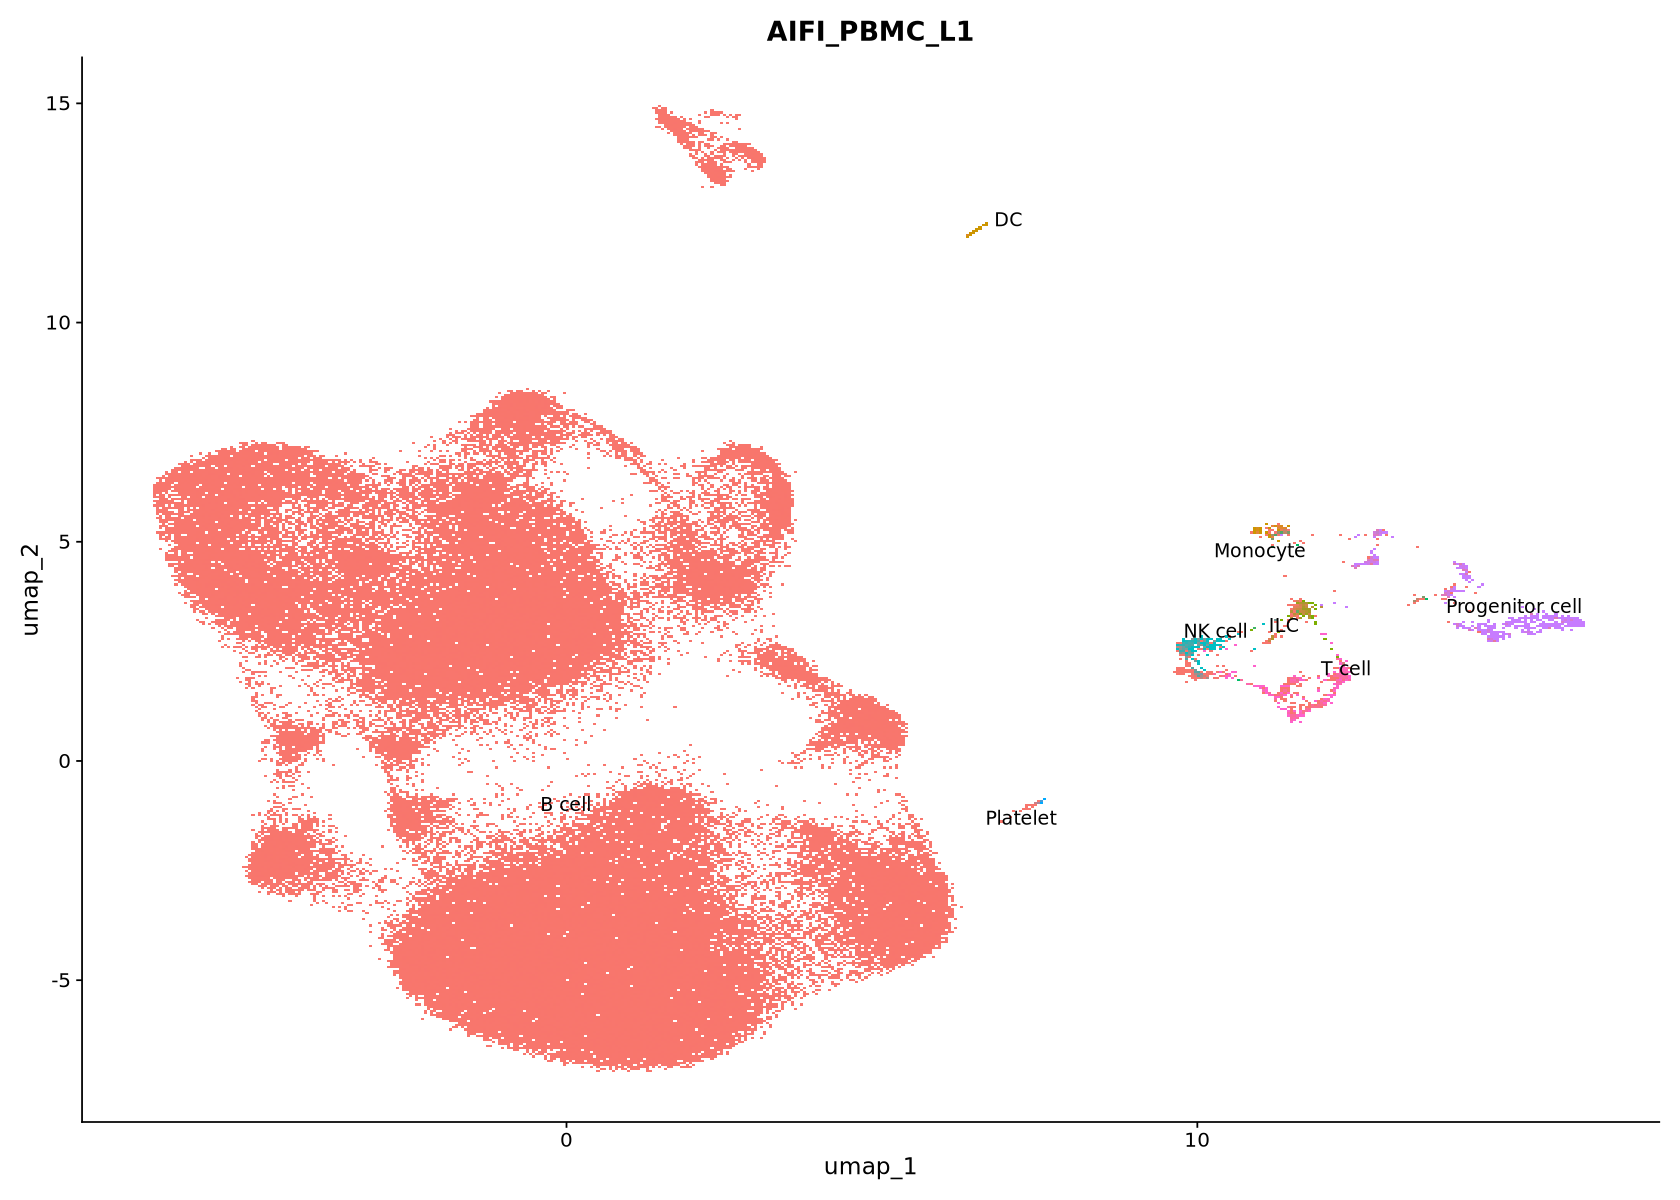

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“ggrepel: 40 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 4 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


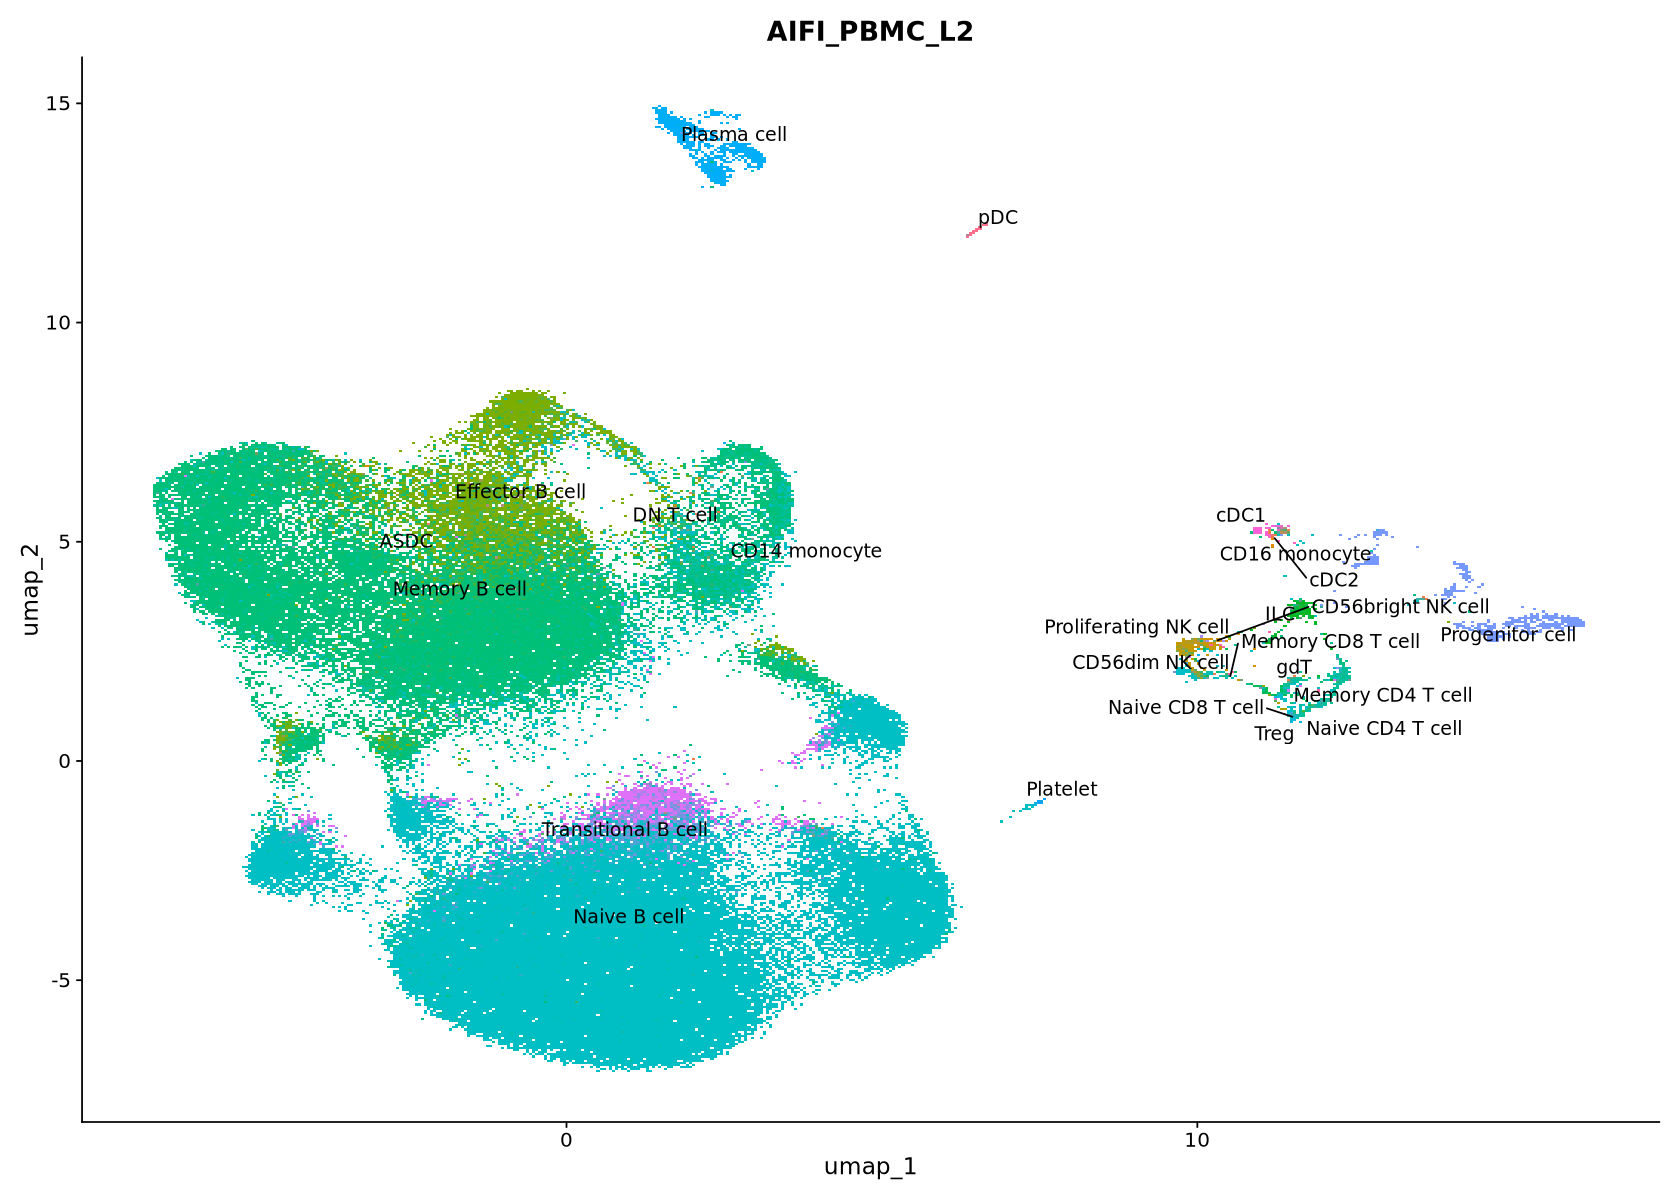

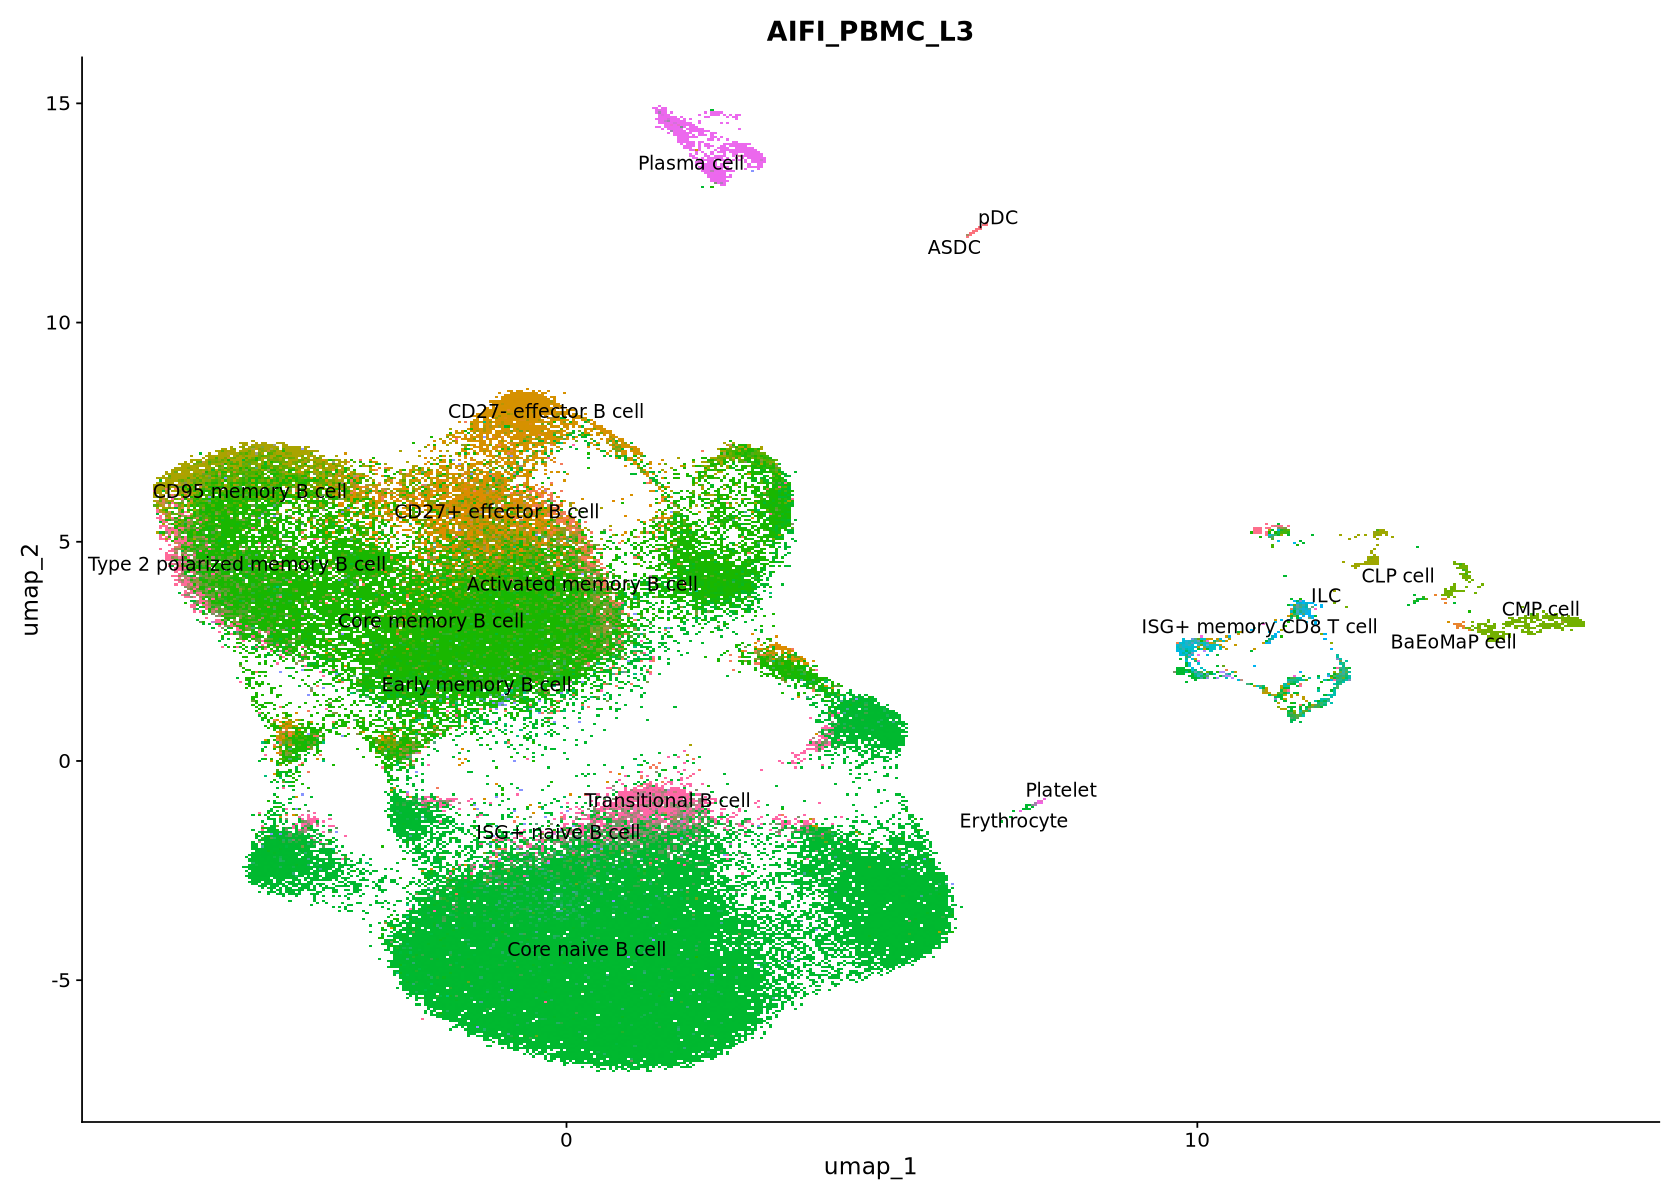

In [19]:
options(repr.plot.width = 14, repr.plot.height = 10)
DimPlot(so_mdata, group.by = 'AIFI_PBMC_L1', label = TRUE, repel = TRUE, shuffle = TRUE) & NoLegend()
DimPlot(so_mdata, group.by = 'AIFI_PBMC_L2', label = TRUE, repel = TRUE, shuffle = TRUE) & NoLegend()
DimPlot(so_mdata, group.by = 'AIFI_PBMC_L3', label = TRUE, repel = TRUE, shuffle = TRUE) & NoLegend()

In [20]:
so_mdata <- FindNeighbors(so_mdata, dims = 1:25) %>% FindClusters(resolution = 0.5)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 111240
Number of edges: 2850022

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8950
Number of communities: 24
Elapsed time: 49 seconds


4 singletons identified. 20 final clusters.



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



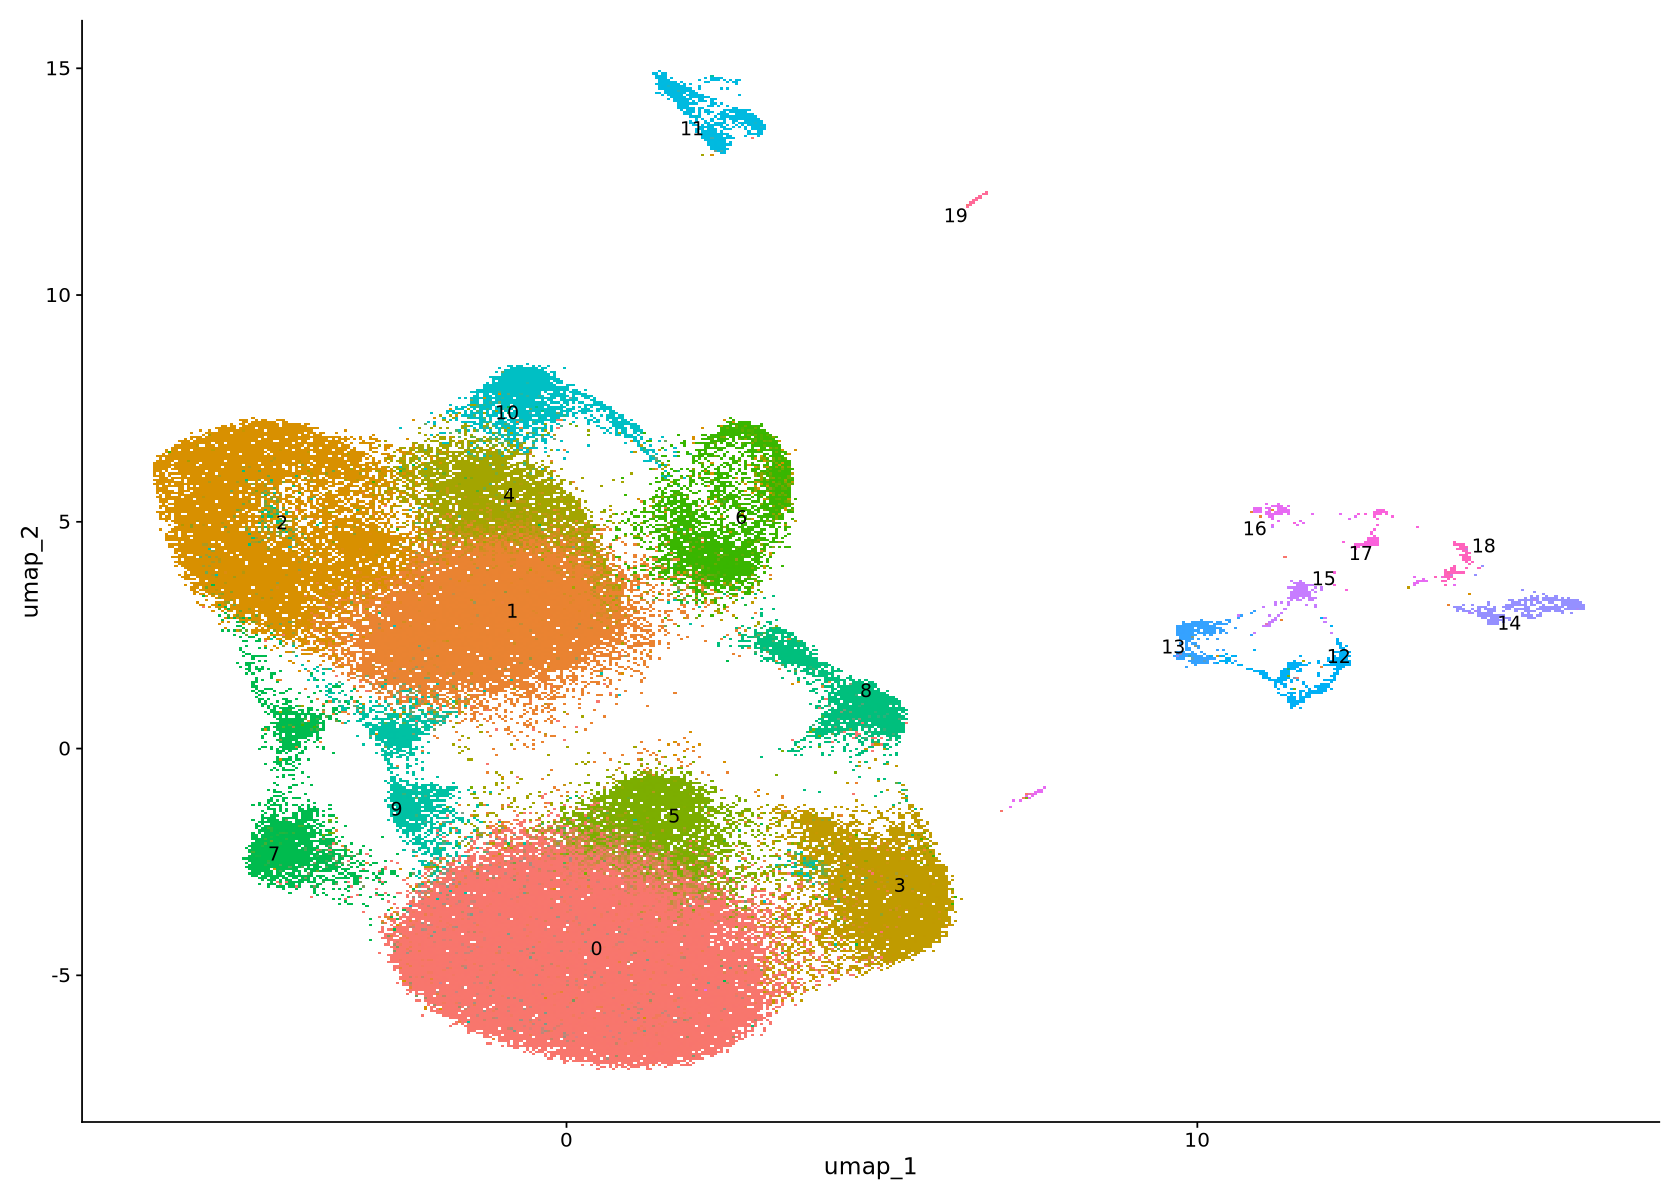

In [21]:
options(repr.plot.width = 14, repr.plot.height = 10)
DimPlot(so_mdata, label = TRUE, repel = TRUE, shuffle = TRUE) & NoLegend()

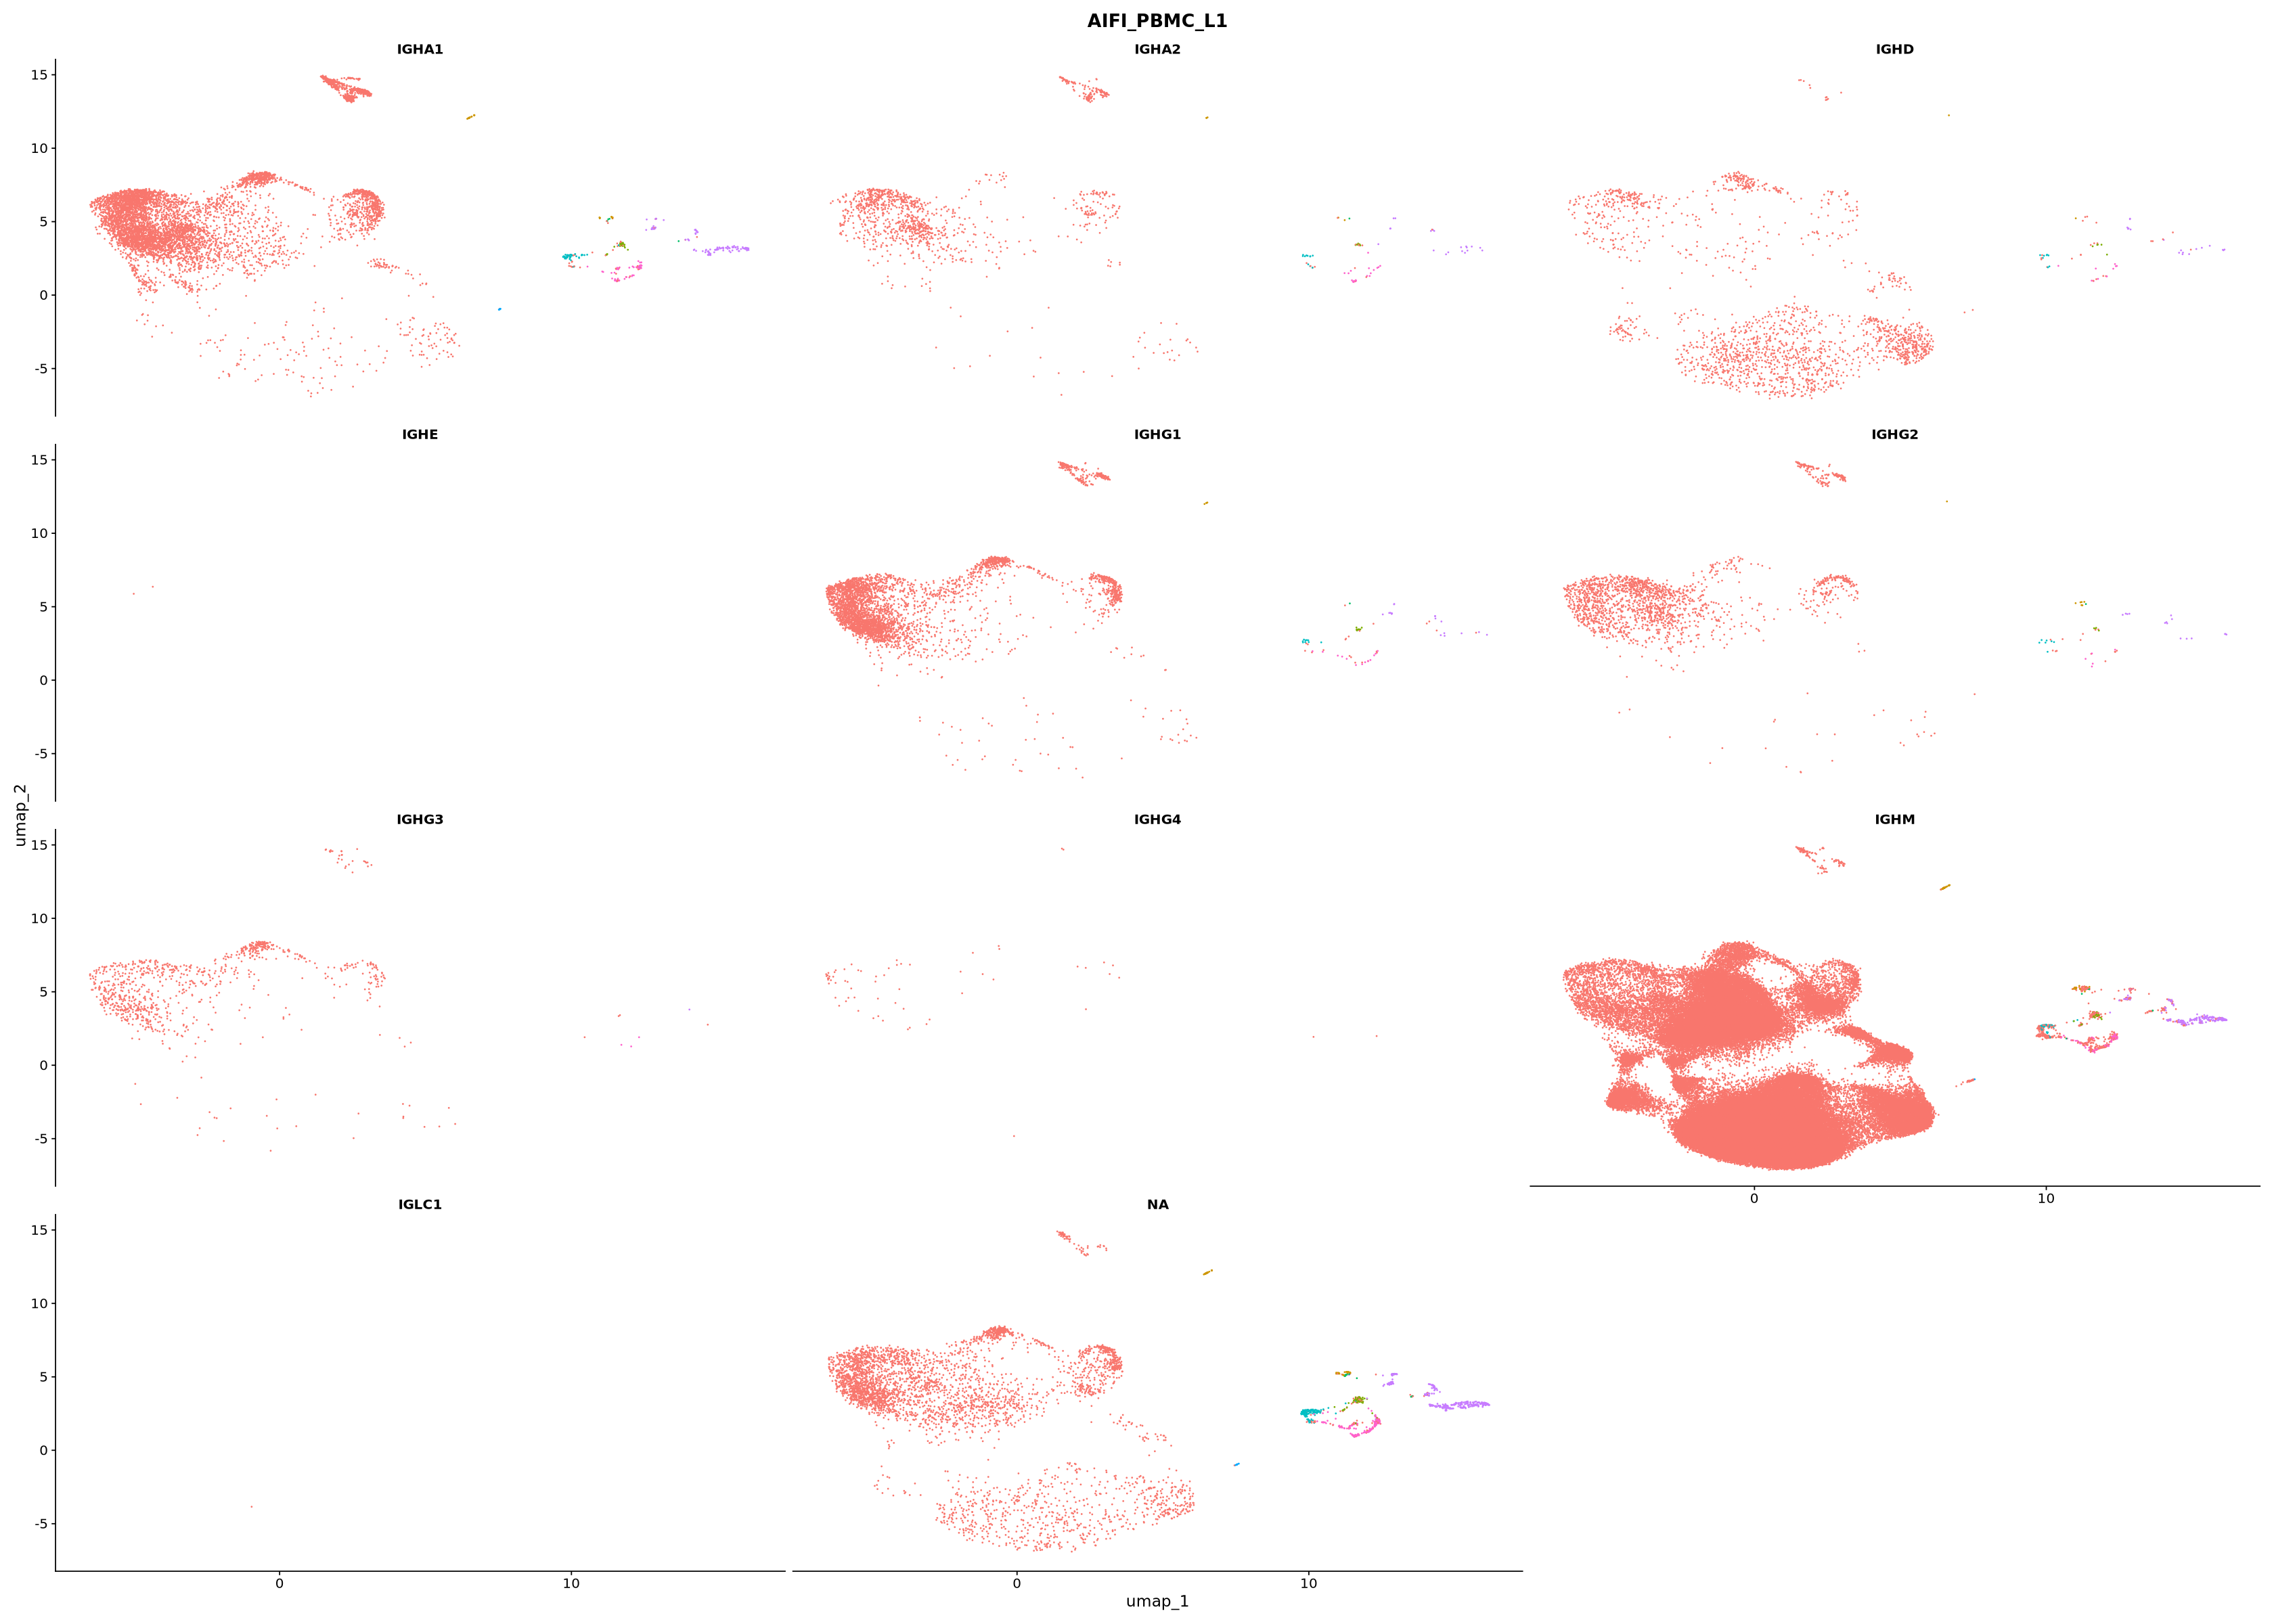

In [22]:
options(repr.plot.width = 28, repr.plot.height = 20)
DimPlot(so_mdata, group.by = 'AIFI_PBMC_L1', split.by = 'igh_c_gene', raster = FALSE, ncol=3) & NoLegend()

In [23]:
df_cluster_purity <- so_mdata@meta.data %>% 
    dplyr::group_by(RNA_snn_res.0.5,igh_c_gene) %>%
    dplyr::summarise(count=n()) %>%
    dplyr::group_by(RNA_snn_res.0.5) %>%
    dplyr::mutate(percentage = (count / sum(count)) * 100)

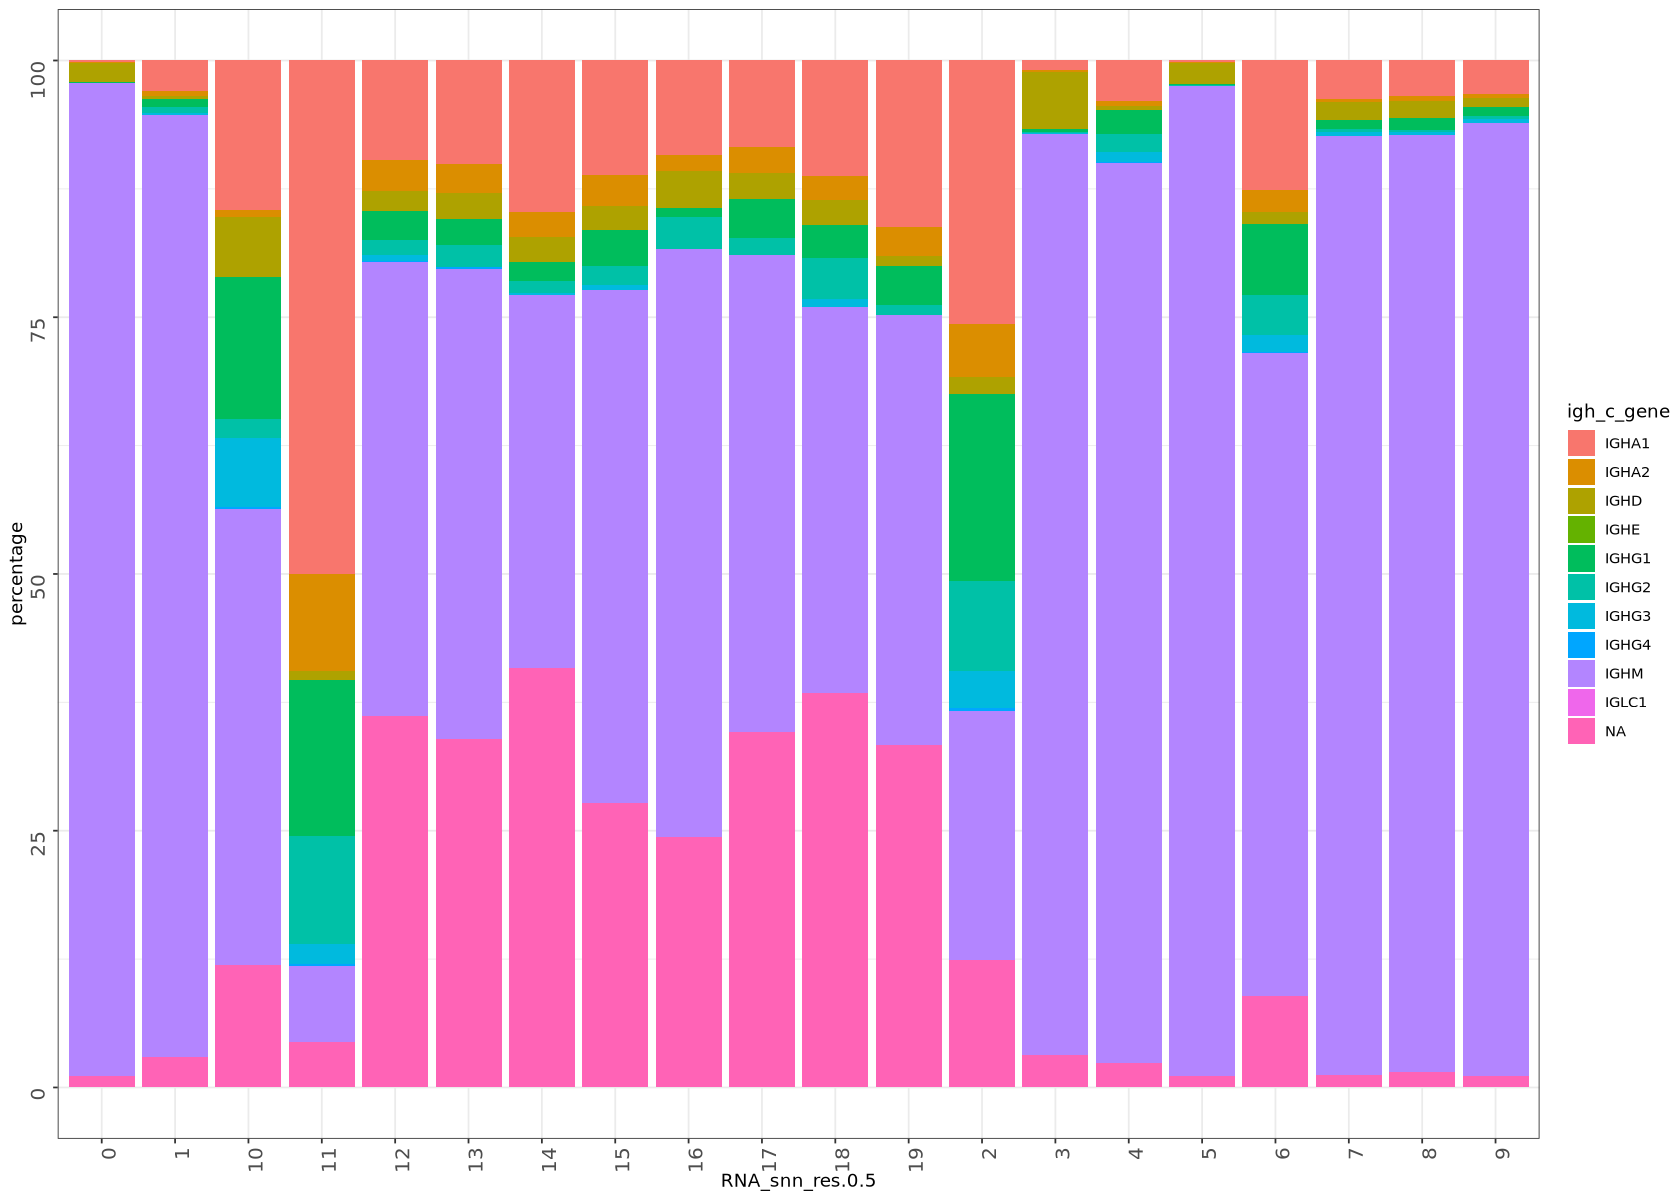

In [24]:
options(repr.plot.width = 14, repr.plot.height = 10)
ggplot(df_cluster_purity, aes(x=RNA_snn_res.0.5, y=percentage, fill=igh_c_gene)) + 
    geom_bar(stat='identity') + 
    theme_bw() +
    theme(axis.text = element_text(size = 12, angle = 90, vjust=1, hjust=1))

In [25]:
cluster_degs <- FindAllMarkers(so_mdata, max.cells.per.ident = 1000)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 14

Calculating cluster 15

Calculating cluster 16

Calculating cluster 17

Calculating cluster 18

Calculating cluster 19



In [26]:
write.csv(cluster_degs, 'cluster_degs.csv')

DEG Results Cluster: 
12 = IL7R
13 = NKG7
14 = GATA2
15 = IL7R
16 = SLC8A1
17 = HOXA9
18 = ZNF521

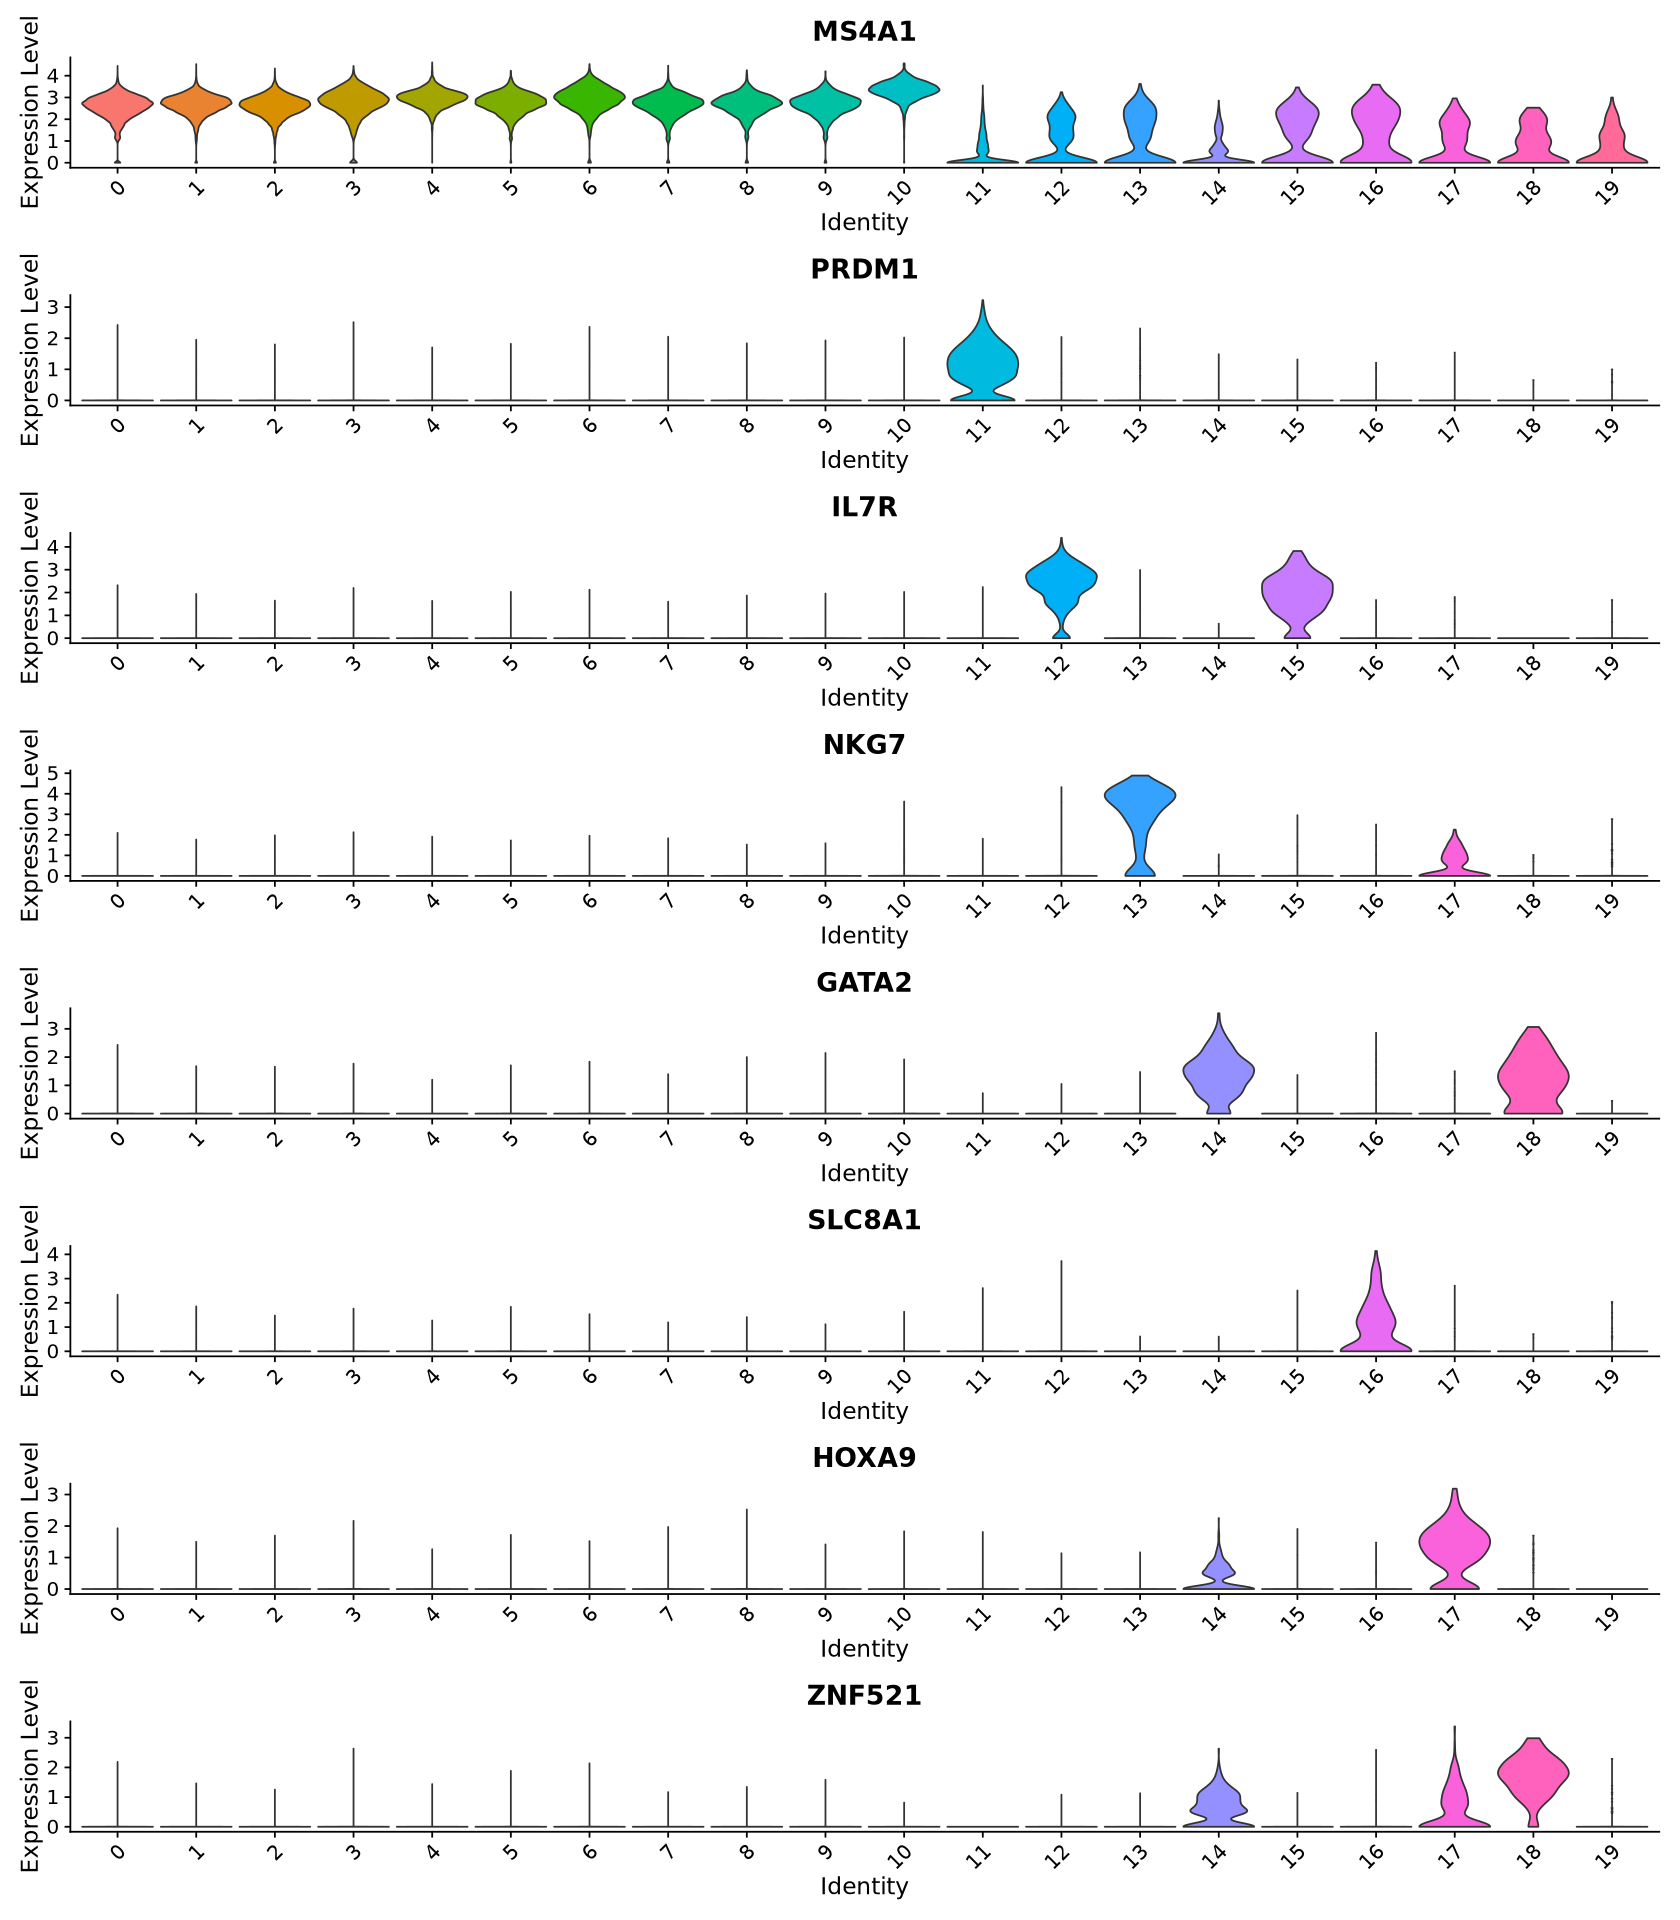

In [27]:
options(repr.plot.width = 14, repr.plot.height = 16)
VlnPlot(so_mdata, features = c('MS4A1','PRDM1','IL7R','NKG7','GATA2','SLC8A1','HOXA9','ZNF521'), pt.size = 0, ncol = 1)

In [28]:
so_clean <- subset(so_mdata, `RNA_snn_res.0.5` %in% c(0,1,2,3,4,5,6,7,8,9,10,11))
so_clean

An object of class Seurat 
36641 features across 108379 samples within 2 assays 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: ADT
 2 dimensional reductions calculated: pca, umap

In [29]:
table(so_clean$AIFI_PBMC_L1)


B cell 
108379 

In [30]:
table(so_clean$AIFI_PBMC_L3)


       Activated memory B cell          CD27+ effector B cell 
                          1921                           3799 
         CD27- effector B cell             CD95 memory B cell 
                          2691                           2854 
            Core memory B cell              Core naive B cell 
                         32695                          58345 
           Early memory B cell              ISG+ naive B cell 
                           390                            968 
                   Plasma cell                       Platelet 
                          1316                              1 
         Proliferating NK cell            Transitional B cell 
                             1                           2433 
Type 2 polarized memory B cell 
                           965 

In [31]:
so_clean <- subset(so_clean, AIFI_PBMC_L3 %in% c('Platelet','Proliferating NK cell'), invert = TRUE)

In [32]:
table(so_clean$AIFI_PBMC_L3)


       Activated memory B cell          CD27+ effector B cell 
                          1921                           3799 
         CD27- effector B cell             CD95 memory B cell 
                          2691                           2854 
            Core memory B cell              Core naive B cell 
                         32695                          58345 
           Early memory B cell              ISG+ naive B cell 
                           390                            968 
                   Plasma cell            Transitional B cell 
                          1316                           2433 
Type 2 polarized memory B cell 
                           965 

In [33]:
so_clean <- NormalizeData(so_clean) %>% FindVariableFeatures() %>% ScaleData() %>% RunPCA() %>% RunUMAP(dims=1:25)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”
PC_ 1 
Positive:  ZBTB20, CDK14, FUT8, AHNAK, RABGAP1L, MED13L, NCOA3, XIST, ARHGAP15, HIPK2 
	   VOPP1, TBC1D9, FBXW7, KLF12, EBF1, PPP3CA, CSGALNACT1, MYO1D, FNDC3A, ARHGAP24 
	   COL4A4, ERC1, RFX3, ANK3, DENND5B, AL355076.2, SSPN, NEAT1, FTX, ATXN1 
Negative:  RPLP1, TMSB4X, RPS18, TCL1A, ACTB, IGHM, JUNB, JUN, IGHD, IL4R 
	   YBX3, H1FX, FOS, KCNG1, STAG3, ACTG1, AL139020.1, FAM177B, CNTNAP2, CD69 
	   IGFBP4, ZDHHC19, SSR4, IFITM1, DUSP6, GADD45B, ZBTB16, MYC, DSP, RHOB 
PC_ 2 
Positive:  BACH2, AFF3, COL19A1, IL4R, CAMK2D, SKAP1, ADK, LIX1-AS1, KHDRBS2, AUTS2 
	   ST6GALNAC3, SSBP2, ARHGAP15, LARGE1, YBX3, AC108879.1, TCL1A, DPYD, LINC01619, WWOX 
	   PCDH9, P2RY14, XYLT1, ARHGAP32, IGHD, CARMIL1, ZBTB16, L3MBTL4, TPST1, KCNH8 
Negative:  CRIP1, GAPDH, RPS18, RPLP1, ACTG1, TNFRSF13B, A

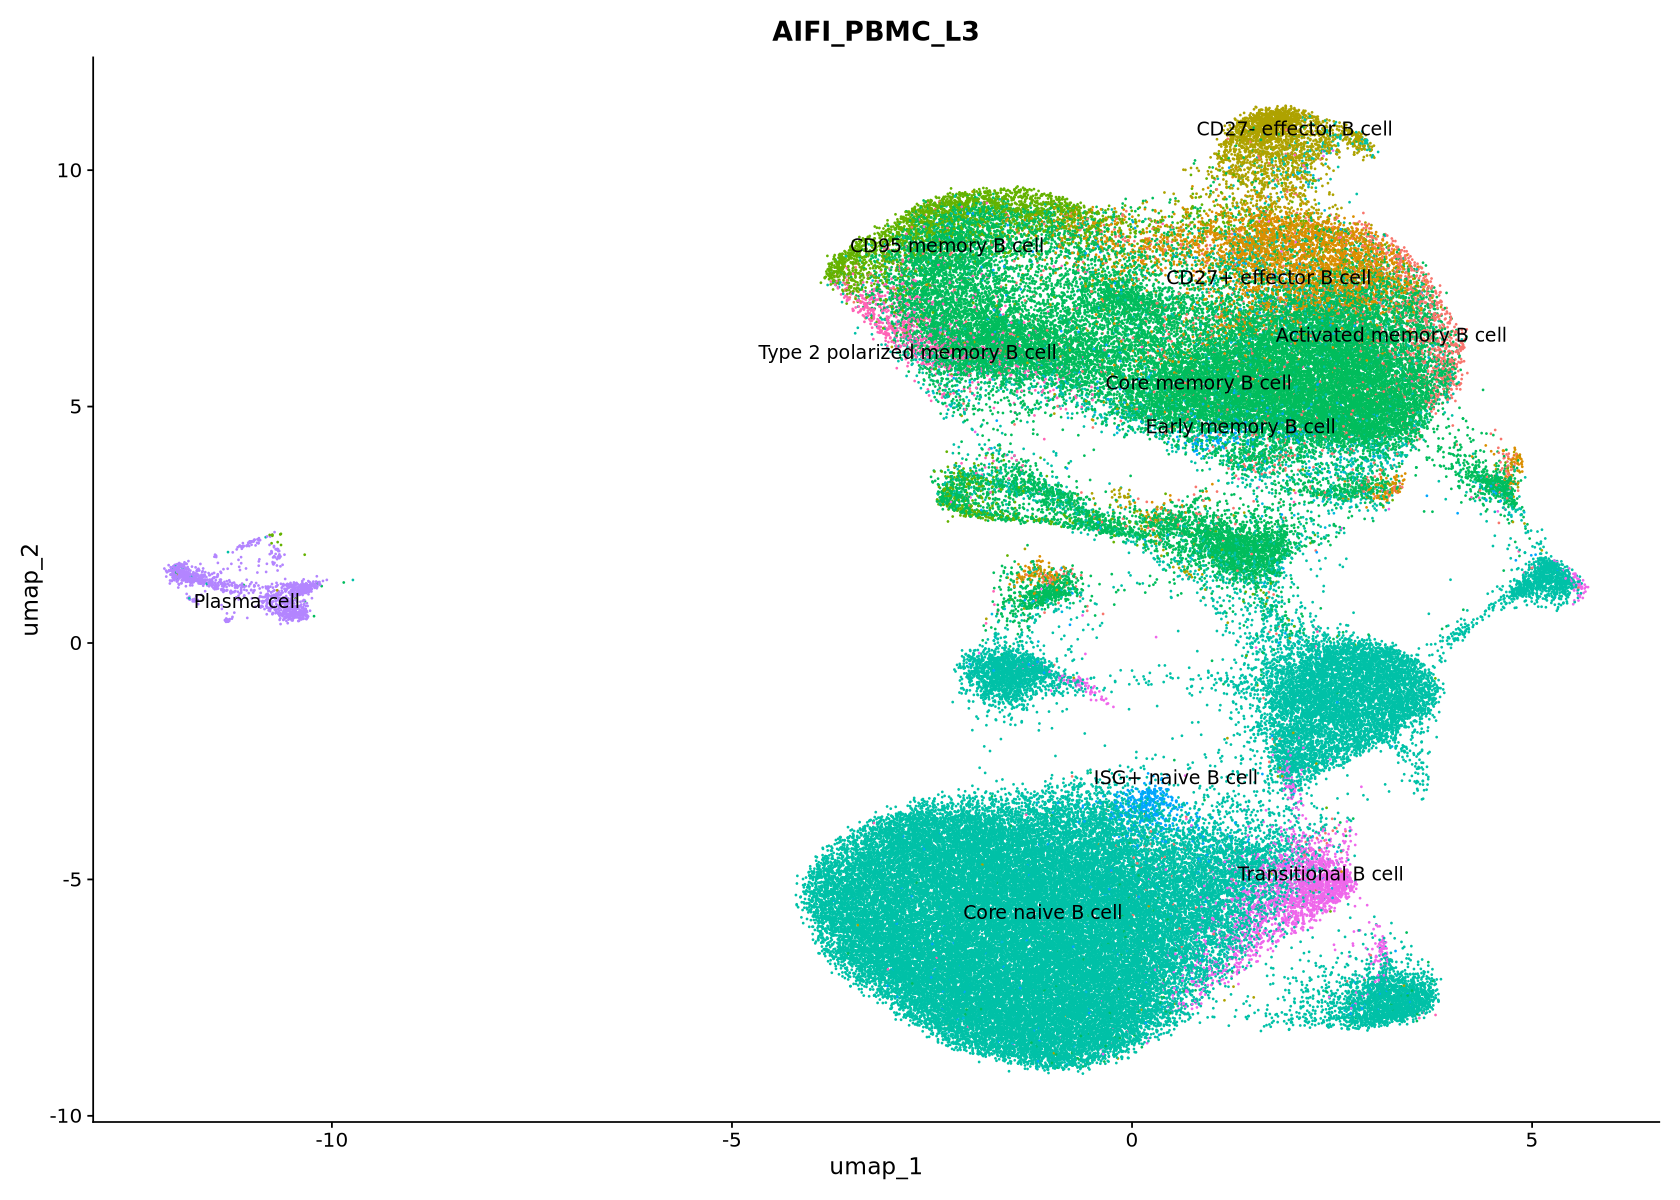

In [34]:
options(repr.plot.width = 14, repr.plot.height = 10)
DimPlot(so_clean, group.by = 'AIFI_PBMC_L3', label = TRUE, repel = TRUE, shuffle = TRUE, raster=FALSE) & NoLegend()

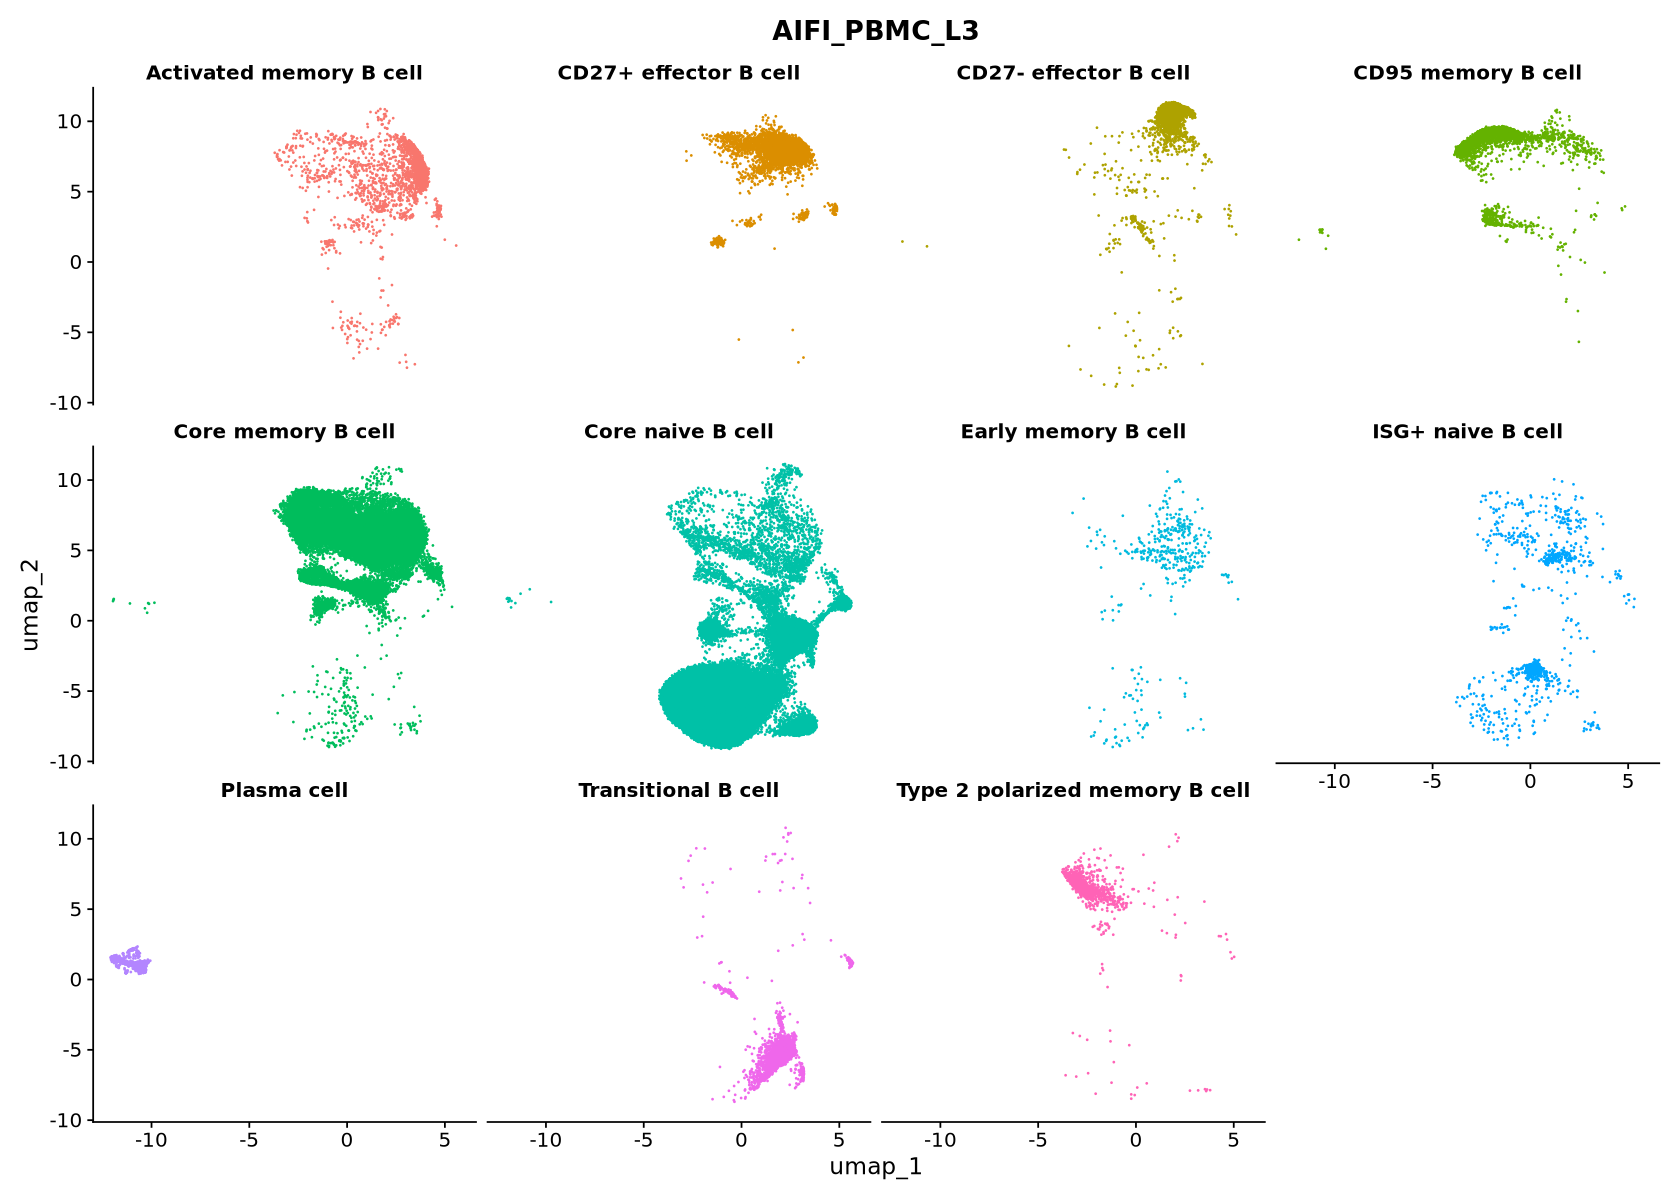

In [35]:
options(repr.plot.width = 14, repr.plot.height = 10)
DimPlot(so_clean, group.by = 'AIFI_PBMC_L3', split.by = 'AIFI_PBMC_L3', raster=FALSE, ncol = 4) & NoLegend()

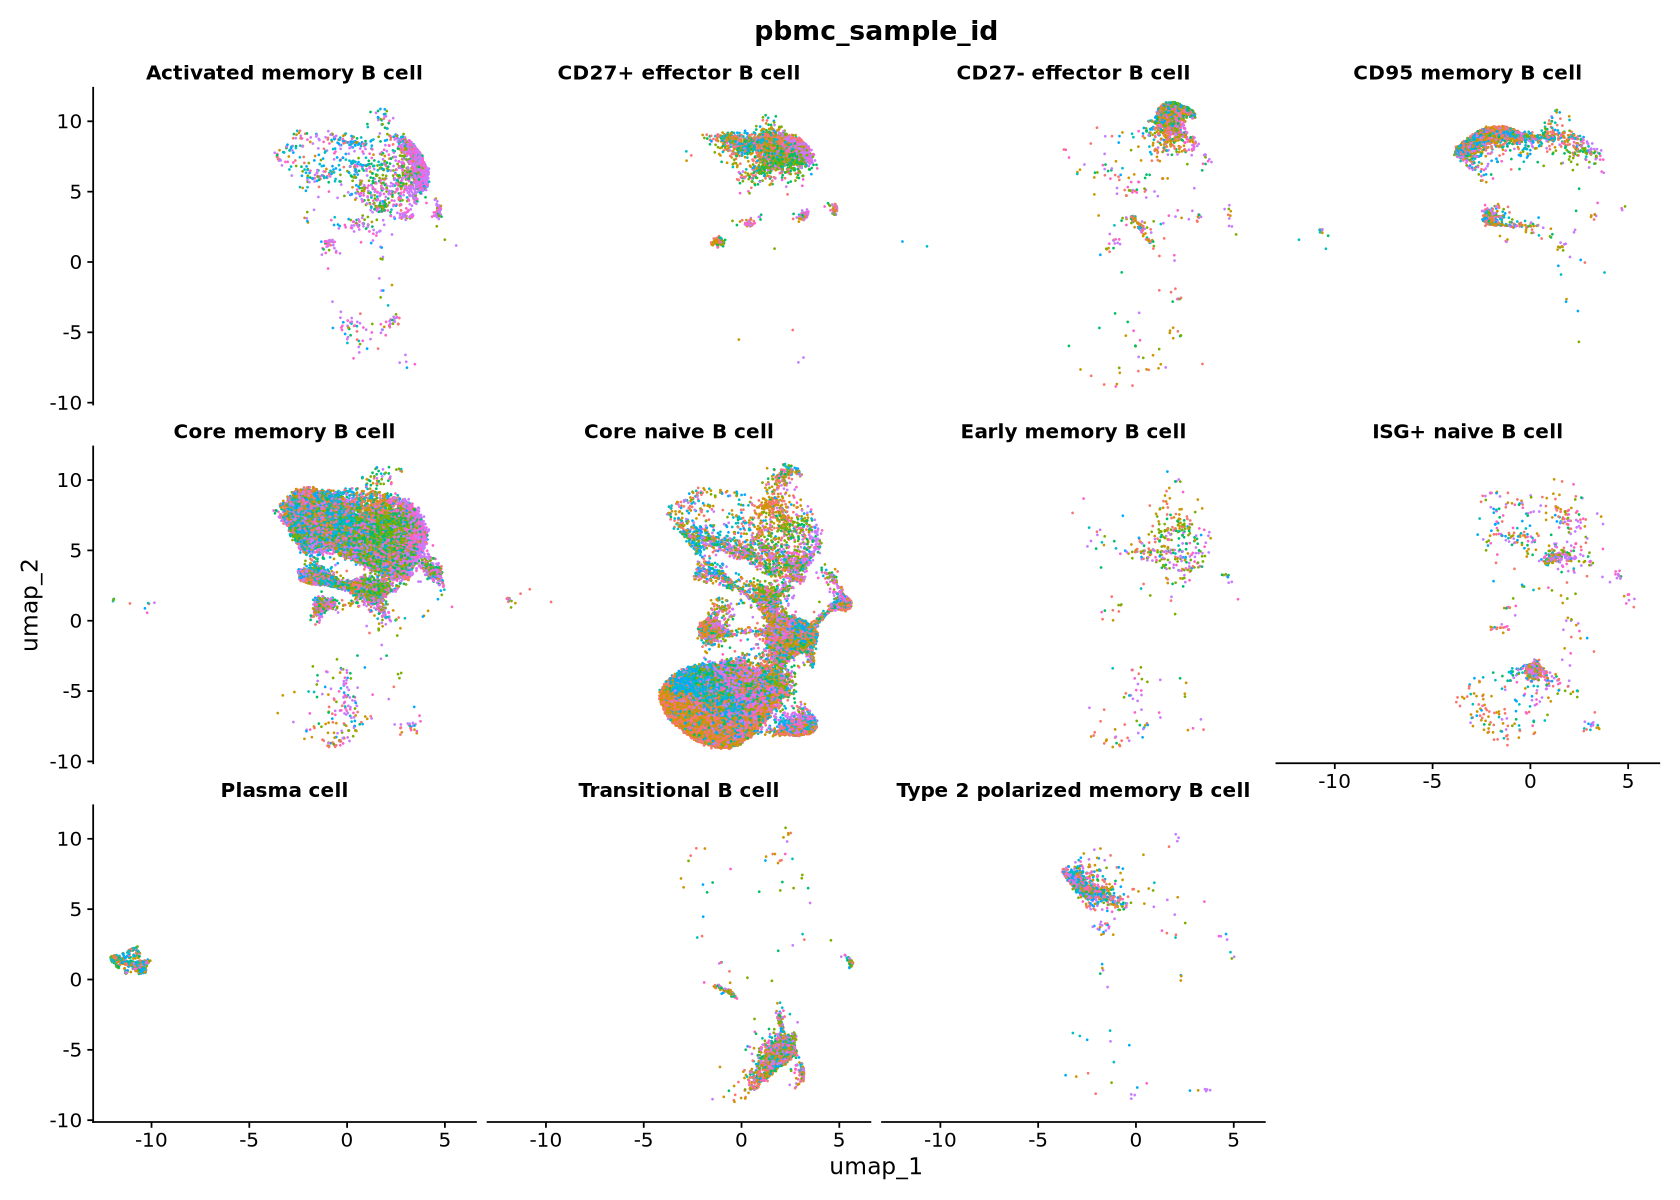

In [36]:
options(repr.plot.width = 14, repr.plot.height = 10)
DimPlot(so_clean, group.by = 'pbmc_sample_id', split.by = 'AIFI_PBMC_L3', raster=FALSE, ncol = 4, shuffle = TRUE) & NoLegend()

In [37]:
saveRDS(so_clean, 'so_clean.rds')

In [38]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/minimal/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] stringr_1.5.1      scRepertoire_2.3.2 dplyr_1.1.4        magrittr_2.0.3    
 [5] ggplot2_3.5.1      H5weaver_1.3.0     rhdf5_2.50.0       Matrix_1.7-2      
 [9] data.table_1.16.4  ggridges_0.5.6     Seurat_5.2.1       SeuratObject_5.0.2
[13] sp_2.1-4          

loaded via a namespace (and not attached):
  [1] cuba